## 데이터 타입 변환 & 결측치 처리 기초

In [1]:
import pandas as pd

# 예시 데이터프레임 생성
data = pd.DataFrame({
    'A':['1', '2', '3'],
    'B':['4', '5', '6'],
    'C':['7', '8', '9']
})

data

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


### apply(pd.to_numeric)
- 선택한 여러 열에 한 번에 숫자 변환 함수를 적용한다.

In [2]:
# 데이터타입을 int로 변경
data[['A', 'B', 'C']].apply(pd.to_numeric)

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


In [3]:
pd.__version__

'3.0.3'

## dropna()
- 결측값이 있는 행 제거
- 가장 간단하지만 데이터가 많이 삭제될 수 있어 신중하게 사용해야 한다.
- 결측치 비율이 매우 낮을 때만 권장한다.
- 기본값은 행 기준(axis=0)
- axis=1 --> 열(컬럼) 기준

In [4]:
data = pd.DataFrame({
    'A':['1', '2', '3', None],
    'B':['4', None, '5', '6'],
    'C':[None, '7', '8', '9']
})

data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [5]:
data.dropna()

,A,B,C
2,3,5,8


## 결측치 0으로 채우기

In [6]:
data.fillna(0)

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


In [7]:
data_fillna0 = data.fillna(0)

data_fillna0

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


## 결측값을 평균으로 채우기 - fillna(mean())
- mean() : 평균
- 숫자형 데이터(나이, 온도, 점수 등)에서 가장 널리 쓰이는 결측치 처리 방식
- 극단적인 이상치가 있으면 평균이 왜곡될 수 있으니, 이상치 제거 후 평균을 채우는 순서가 안전하다.

In [8]:
data_numeric = data.apply(pd.to_numeric) # 숫자형으로 변환

data_numeric

,A,B,C
0,1.0,4.0,NaN
1,2.0,NaN,7.0
2,3.0,5.0,8.0
3,NaN,6.0,9.0


In [9]:
data_numeric.fillna(data_numeric.mean())

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


In [11]:
avg = data_numeric.mean()

data_numeric = data_numeric.fillna(avg) # 덮어쓰기

## 결측값을 최빈값으로 채우기 

### 최빈값 : mode()
- 해당 열에서 가장 자주 나온 값들을 리스트 형태로 변환
- 최빈값이 여러개 여도 첫번째값 불러오기 --> [0]

In [12]:
mode_a = data['A'].mode()

mode_a

0    1
1    2
2    3
Name: A, dtype: str

In [13]:
mode_b = data['B'].mode()[0]

mode_b

'4'

In [14]:
mode_c = data['C'].mode()[0]

mode_c

'7'

In [15]:
data.fillna(mode_b)

,A,B,C
0,1,4,4
1,2,4,7
2,3,5,8
3,4,6,9


In [16]:
# 데이터프레임의 열마다 같은 코드를 반복 적용시킬때
data.apply(lambda x: x.fillna(x.mode()[0])) 

,A,B,C
0,1,4,7
1,2,4,7
2,3,5,8
3,1,6,9


In [17]:
# lambda 매개변수: 함수 몸통(리턴값)
f = lambda x: x + 1  # 매개변수 x에 +1을 한다. 

f(2) # 매개변수 x자리에 2가 들어갔다. -> +1을 했다 -> 결과 3이 나왔다 

3

In [18]:
result = f(5)
result

6

## 열마다 다른 값으로 결측치 대체 (딕셔너리 활용)
- 열마다 성격이 다를때 사용
- 성별은 최빈값, 지역은 '기타'

In [19]:
data2 = pd.DataFrame({
    '성별':['남', '남', '여', '남', None, '여'],
    '지역':['대구', '서울', '서울', None, '대구', None],
    '나이':[20, 30, None, None, 38, 22]
})

data2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,NaN
3,남,NaN,NaN
4,NaN,대구,38.0
5,여,NaN,22.0


In [20]:
data2_fillna = data2.fillna({'성별':'남', '지역':'기타', '나이':20})

data2_fillna

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,20.0
3,남,기타,20.0
4,남,대구,38.0
5,여,기타,22.0


In [ ]:
data2_fillna2 = data2.fillna({'성별': data2['성별'].mode()[0], # 최빈값
                              '지역':'기타',                   # 값을 직접 대입
                              '나이': data2['나이'].mean()})   # 평균
data2_fillna2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,27.5
3,남,기타,27.5
4,남,대구,38.0
5,여,기타,22.0


: 

{'whiskers': [<matplotlib.lines.Line2D at 0x1a2848d8510>,
 'caps': [<matplotlib.lines.Line2D at 0x1a2848d9e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a2448af090>,
 'medians': [<matplotlib.lines.Line2D at 0x1a2848db790>,
 'fliers': [<matplotlib.lines.Line2D at 0x1a2848e8390>,
 'means': []}

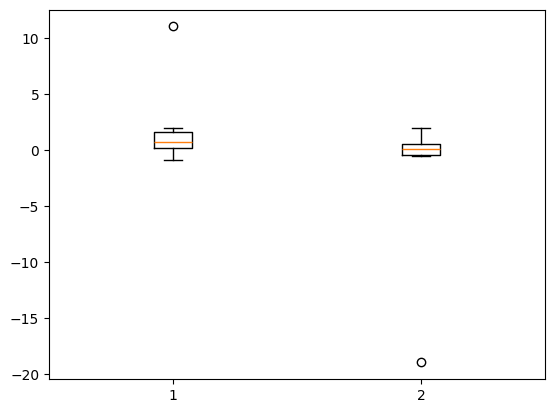

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.DataFrame(np.random.randn(8, 3),
                columns=['C1', 'C2', 'C3'])
df.loc[1,'C1']=11
df.loc[3,'C3']= -19
plt.boxplot([df['C1'],df['C3']])

데이터프레임.corr()
- 열들 사이의 상관계수 (-1 ~ 1)를 계산한 표
- 1에 가까우면 강한 양의 상관관계
- -1에 가까우면 강한 음의 상관관계
- heatmap 그래프로 상관관계를 표현할 수 있다.
    - annot = Ture: 히트맵의 각 칸에 실제 상관계수 숫자를 함께 표시해준다.

<Axes: >

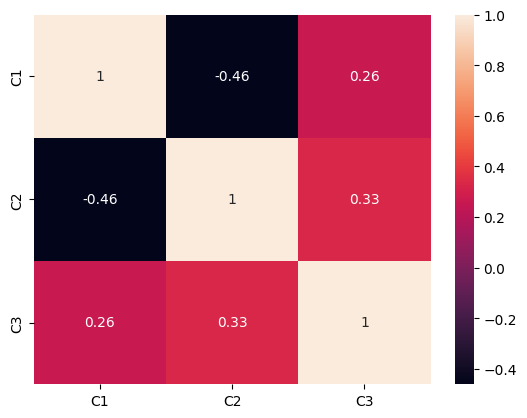

In [2]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)